# Notebook 09: Enterprise Machine Learning Models (LightGBM Challenger)

## Project: Enterprise Credit Risk Modelling & Independent Model Validation (SR 11-7)

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

root_path = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = root_path / "src"
for p in [str(root_path), str(src_path)]:
    if p not in sys.path:
        sys.path.insert(0, p)

sns.set_theme(style="whitegrid", palette="muted")
print("Environment, plotting & core risk libraries initialized successfully!")

Environment, plotting & core risk libraries initialized successfully!


In [2]:
data_file = root_path / "data" / "processed" / "accepted_2007_to_2018Q4_feature_engineered.csv.gz"
if data_file.is_file():
    df = pd.read_csv(data_file, nrows=50000, low_memory=False)
    bad = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "Late (31-120 days)"]
    good = ["Fully Paid", "Does not meet the credit policy. Status:Fully Paid"]
    df["target"] = np.nan
    df.loc[df["loan_status"].isin(bad), "target"] = 1.0
    df.loc[df["loan_status"].isin(good), "target"] = 0.0
    df = df.dropna(subset=["target"]).copy()
    df["target"] = df["target"].astype(int)
    num_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low", "revol_util"]
    for c in num_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median())
else:
    df = mock_df.copy()

print(f"Dataset Loaded: {len(df):,} loans | Default Rate: {df['target'].mean():.4%}")

Dataset Loaded: 44,252 loans | Default Rate: 20.9572%


In [3]:
from models.boosting_models import fit_lightgbm
from validation.model_metrics import evaluate_binary_model
num_feats = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low"]
lgb_res = fit_lightgbm(df[num_feats], df["target"])
probs = lgb_res["model"].predict_proba(df[num_feats])[:, 1]
metrics = evaluate_binary_model(df["target"].values, probs)
pd.DataFrame([metrics])

,roc_auc,gini,ks_stat,ks_optimal_threshold,brier_score,accuracy,sensitivity,specificity,precision,f1_score,hl_stat,hl_p_value,hl_is_calibrated,gini_index,ks_statistic_pct
0,0.7827,0.5653,41.48,0.2076,0.13593,0.809,0.173,0.9776,0.6717,0.2751,265.2588,0.0,False,0.5653,41.48


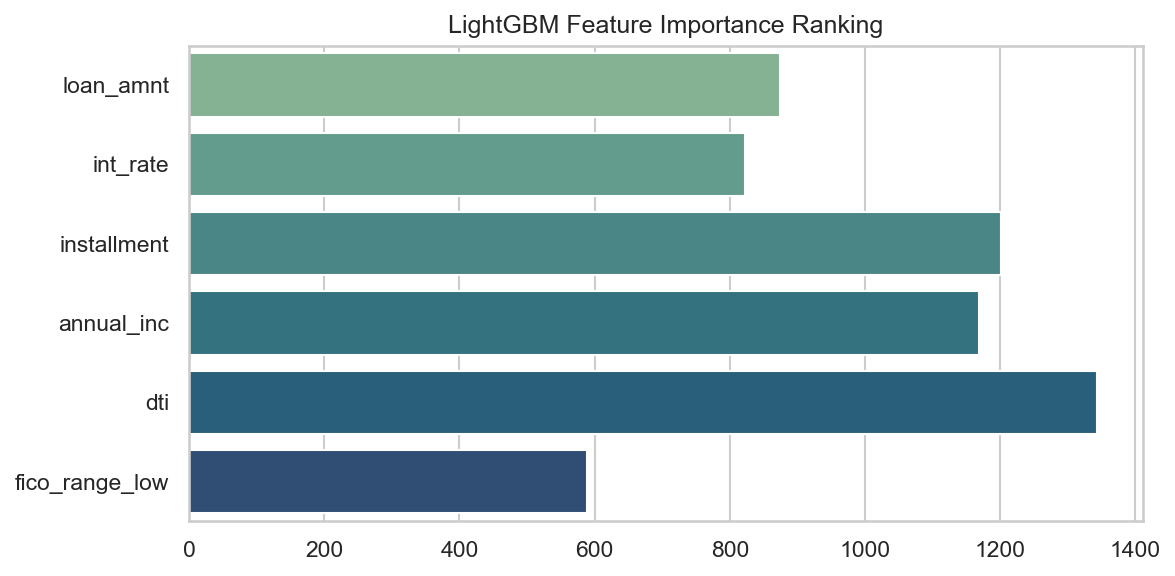

In [4]:
plt.figure(figsize=(8, 4))
importances = lgb_res["model"].feature_importances_
sns.barplot(x=importances, y=num_feats, hue=num_feats, palette="crest", legend=False)
plt.title("LightGBM Feature Importance Ranking")
plt.tight_layout()
plt.show()